# Compute HDSBCAN clusters for pre- and post-QC feature spaces

We apply PCA first to the feature spaces before computing HDBSCAN.

In [1]:
import pathlib
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from plotnine import (
    aes,
    element_text,
    geom_bar,
    ggplot,
    labs,
    position_stack,
    scale_fill_manual,
    theme,
)
from sklearn.cluster import HDBSCAN
from sklearn.decomposition import PCA

# Ignore warning about deprecated argument name in sklearn
warnings.filterwarnings("ignore", message="'force_all_finite' was renamed")

In [2]:
# Output dir for figure
output_dir = pathlib.Path("./figures")
output_dir.mkdir(exist_ok=True, parents=True)

# Load in pre- and post-QC feature selected profiles
pre_QC_df = pd.read_parquet(
    pathlib.Path(
        "/media/18tbdrive/1.Github_Repositories/cellpainting_predicts_cardiac_fibrosis/3.process_cfret_features/data/single_cell_profiles/localhost230405150001_sc_feature_selected_no_QC.parquet"
    )
)
post_QC_df = pd.read_parquet(
    pathlib.Path(
        "/media/18tbdrive/1.Github_Repositories/cellpainting_predicts_cardiac_fibrosis/3.process_cfret_features/data/single_cell_profiles/localhost230405150001_sc_feature_selected.parquet"
    )
)

# Add QC status to pre_QC_df based on matching rows in post_QC_df using metadata
# Set all rows to failed first
pre_QC_df["Metadata_QC_status"] = "failed"
# Find rows in pre_QC_df that are in post_QC_df based on metadata set to passing
metadata_cols = [
    "Metadata_Well",
    "Metadata_Site",
    "Metadata_Nuclei_Location_Center_X",
    "Metadata_Nuclei_Location_Center_Y",
]
# Create a MultiIndex for fast lookup
qc_index = post_QC_df.set_index(metadata_cols).index
mask = pre_QC_df.set_index(metadata_cols).index.isin(qc_index)
pre_QC_df.loc[mask, "Metadata_QC_status"] = "passed"  # rows matching post-QC are passed

# Set min cluster size for HDBSCAN
min_cluster_size = 50

## Compute individual scores

### Pre-QC UMAP scores

Total explained variance by first 5 PCs: 36.99%


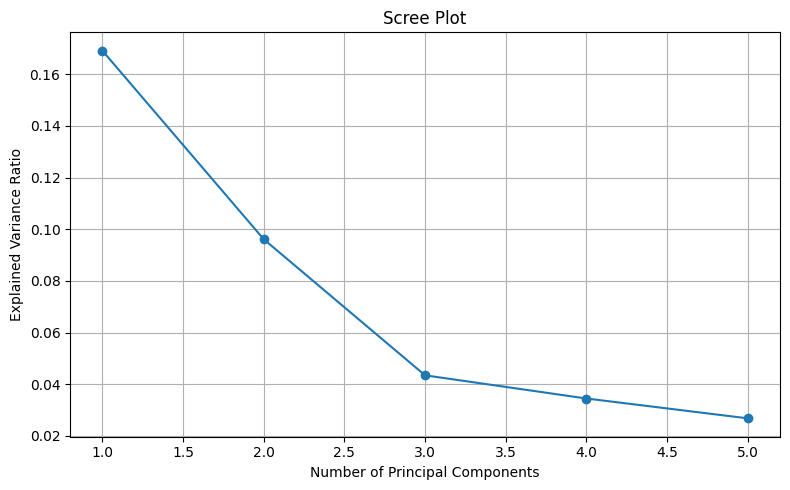

In [3]:
# Isolate just the feature space from Metadata in dataframe
pre_X = pre_QC_df.loc[:, ~pre_QC_df.columns.str.startswith("Metadata_")].values

# Run PCA on pre-QC feature space
pca = PCA(n_components=5, random_state=0)
pre_QC_pca = pca.fit_transform(pre_X)

# Print the total explained variance percentage for the first 5 PCs
explained_variance = np.sum(pca.explained_variance_ratio_) * 100
print(f"Total explained variance by first 5 PCs: {explained_variance:.2f}%")

# Create scree plot to show variance explained by each PC
plt.figure(figsize=(8, 5))
plt.plot(
    np.arange(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    marker="o",
)
plt.xlabel("Number of Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.grid()
plt.tight_layout()
plt.show()

In [4]:
# Run HDBSCAN using sklearn compatible interface
clusterer = HDBSCAN(min_cluster_size=min_cluster_size, n_jobs=-1)
pre_cluster_labels = clusterer.fit_predict(pre_QC_pca)

# Attach cluster labels to the original dataframe
pre_QC_df["cluster"] = pre_cluster_labels

# Info about clusters
print("Unique cluster labels (-1 is noise):", np.unique(pre_cluster_labels))

# Make a dataframe for enrichment analysis: only metadata + cluster label
metadata_cols = [col for col in pre_QC_df.columns if col.startswith("Metadata_")]
pre_enrichment_df = pre_QC_df[[*metadata_cols, "cluster"]].copy()

# Exclude noise points if you want enrichment only on real clusters
pre_enrichment_df = pre_enrichment_df[pre_enrichment_df["cluster"] != -1]
print(pre_enrichment_df.shape)
pre_enrichment_df.head()

Unique cluster labels (-1 is noise): [-1  0  1]
(18524, 21)


,Metadata_WellRow,Metadata_WellCol,Metadata_heart_number,Metadata_cell_type,Metadata_heart_failure_type,Metadata_treatment,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y,Metadata_Cells_Location_Center_X,Metadata_Cells_Location_Center_Y,...,Metadata_ImageNumber,Metadata_Plate,Metadata_Well,Metadata_Cells_Number_Object_Number,Metadata_Cytoplasm_Parent_Cells,Metadata_Cytoplasm_Parent_Nuclei,Metadata_Nuclei_Number_Object_Number,Metadata_Site,Metadata_QC_status,cluster
0,B,2,9,failing,rejected,DMSO,221.046761,137.115493,246.602800,109.285755,...,1,localhost230405150001,B02,1,1,6,6,f00,passed,0
1,B,2,9,failing,rejected,DMSO,690.596142,183.067828,716.170091,177.132195,...,1,localhost230405150001,B02,2,2,7,7,f00,passed,0
2,B,2,9,failing,rejected,DMSO,626.561490,206.923698,623.943740,199.906440,...,1,localhost230405150001,B02,3,3,8,8,f00,passed,0
3,B,2,9,failing,rejected,DMSO,559.448583,220.688160,528.646623,196.955552,...,1,localhost230405150001,B02,4,4,9,9,f00,passed,0
4,B,2,9,failing,rejected,DMSO,909.019946,247.694340,897.965996,253.621836,...,1,localhost230405150001,B02,5,5,10,10,f00,passed,0


### Post-QC UMAP scores

Total explained variance by first 5 PCs: 32.96%


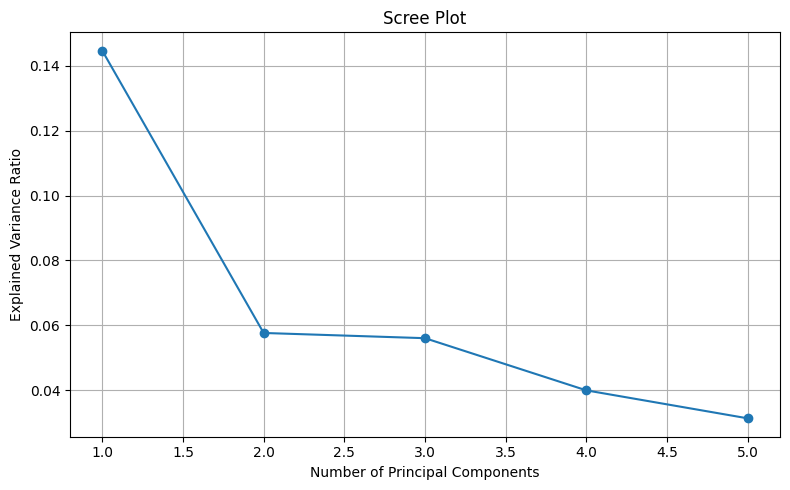

In [5]:
# Isolate just the feature space from Metadata in dataframe
post_X = post_QC_df.loc[:, ~post_QC_df.columns.str.startswith("Metadata_")].values

# Run PCA on post-QC feature space
pca = PCA(n_components=5, random_state=0)
post_QC_pca = pca.fit_transform(post_X)

# Print the total explained variance percentage for the first 5 PCs
explained_variance = np.sum(pca.explained_variance_ratio_) * 100
print(f"Total explained variance by first 5 PCs: {explained_variance:.2f}%")

# Create scree plot to show variance explained by each PC
plt.figure(figsize=(8, 5))
plt.plot(
    np.arange(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    marker="o",
)
plt.xlabel("Number of Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.grid()
plt.tight_layout()
plt.show()

In [6]:
# Run HDBSCAN using sklearn compatible interface
clusterer = HDBSCAN(min_cluster_size=min_cluster_size, n_jobs=-1)
post_cluster_labels = clusterer.fit_predict(post_QC_pca)

# Attach cluster labels to the original dataframe
post_QC_df["cluster"] = post_cluster_labels

# Info about clusters
print("Unique cluster labels (-1 is noise):", np.unique(post_cluster_labels))

# Make a dataframe for enrichment analysis: only metadata + cluster label
metadata_cols = [col for col in post_QC_df.columns if col.startswith("Metadata_")]
post_enrichment_df = post_QC_df[[*metadata_cols, "cluster"]].copy()

# Exclude noise points if you want enrichment only on real clusters
post_enrichment_df = post_enrichment_df[post_enrichment_df["cluster"] != -1]
print(post_enrichment_df.shape)
post_enrichment_df.head()

Unique cluster labels (-1 is noise): [-1  0  1  2]
(1450, 20)


,Metadata_WellRow,Metadata_WellCol,Metadata_heart_number,Metadata_cell_type,Metadata_heart_failure_type,Metadata_treatment,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y,Metadata_Cells_Location_Center_X,Metadata_Cells_Location_Center_Y,Metadata_Image_Count_Cells,Metadata_ImageNumber,Metadata_Plate,Metadata_Well,Metadata_Cells_Number_Object_Number,Metadata_Cytoplasm_Parent_Cells,Metadata_Cytoplasm_Parent_Nuclei,Metadata_Nuclei_Number_Object_Number,Metadata_Site,cluster
16,B,2,9,failing,rejected,DMSO,837.084276,552.947398,840.452522,540.446958,40,1,localhost230405150001,B02,19,19,26,26,f00,1
19,B,2,9,failing,rejected,DMSO,804.752274,625.758159,789.908604,638.665591,40,1,localhost230405150001,B02,22,22,31,31,f00,1
27,B,2,9,failing,rejected,DMSO,735.961026,834.631475,754.307418,799.787045,40,1,localhost230405150001,B02,30,30,41,41,f00,1
28,B,2,9,failing,rejected,DMSO,916.114325,837.045914,921.676069,845.036480,40,1,localhost230405150001,B02,31,31,42,42,f00,1
30,B,2,9,failing,rejected,DMSO,551.152184,874.413763,520.770840,862.416540,40,1,localhost230405150001,B02,33,33,44,44,f00,1


# Visualize where passing or failing cells are within each cluster

cluster
0    17530
1      994
Name: count, dtype: int64


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 8 x 5 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: figures/pre_QC_cluster_qc_status_proportions.png


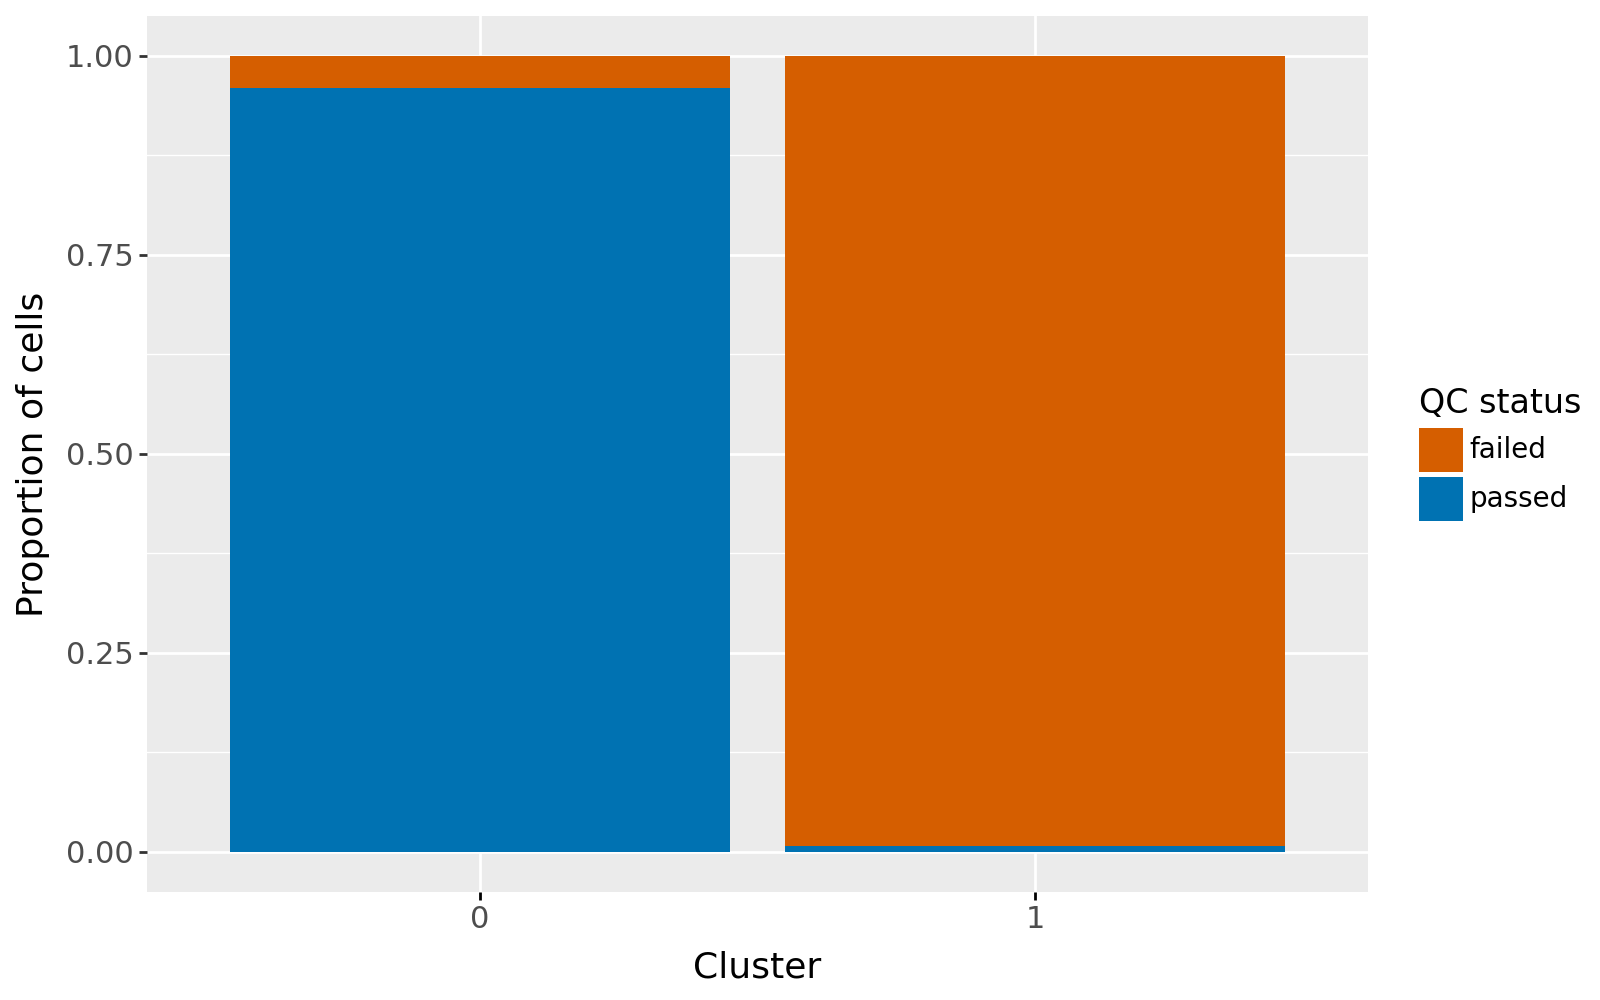

In [7]:
# Attach cluster labels to full dataframe
pre_QC_clusters_df = pre_QC_df.copy()
pre_QC_clusters_df["cluster"] = pre_cluster_labels

# Drop noise
pre_QC_clusters_df = pre_QC_clusters_df[pre_QC_clusters_df["cluster"] != -1]

# Convert labels to string for nicer plotting
pre_QC_clusters_df["cluster"] = pre_QC_clusters_df["cluster"].astype(str)

# Print number of cells in each cluster
print(pre_QC_clusters_df["cluster"].value_counts().sort_index())

# Calculate proportions for each cluster
cluster_counts = (
    pre_QC_clusters_df.groupby(["cluster", "Metadata_QC_status"])
    .size()
    .unstack(fill_value=0)
)
cluster_props = (
    cluster_counts.div(cluster_counts.sum(axis=1), axis=0)
    .reset_index()
    .melt(id_vars="cluster", var_name="QC_status", value_name="proportion")
)

# Plot
p = (
    ggplot(cluster_props, aes(x="cluster", y="proportion", fill="QC_status"))
    + geom_bar(stat="identity", position=position_stack())
    + scale_fill_manual(values={"passed": "#0072B2", "failed": "#D55E00"})
    + labs(
        x="Cluster",
        y="Proportion of cells",
        fill="QC status",
    )
    + theme(
        figure_size=(8, 5),
        axis_text_x=element_text(size=11),
        axis_text_y=element_text(size=11),
        axis_title_x=element_text(size=13),
        axis_title_y=element_text(size=13),
        legend_title=element_text(size=12),
        legend_text=element_text(size=10),
    )
)

p.save(output_dir / "pre_QC_cluster_qc_status_proportions.png", dpi=300)
p.show()

cluster
0     265
1    1050
2     135
Name: count, dtype: int64


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 10 x 6 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: figures/post_QC_cluster_treatment_celltype.png


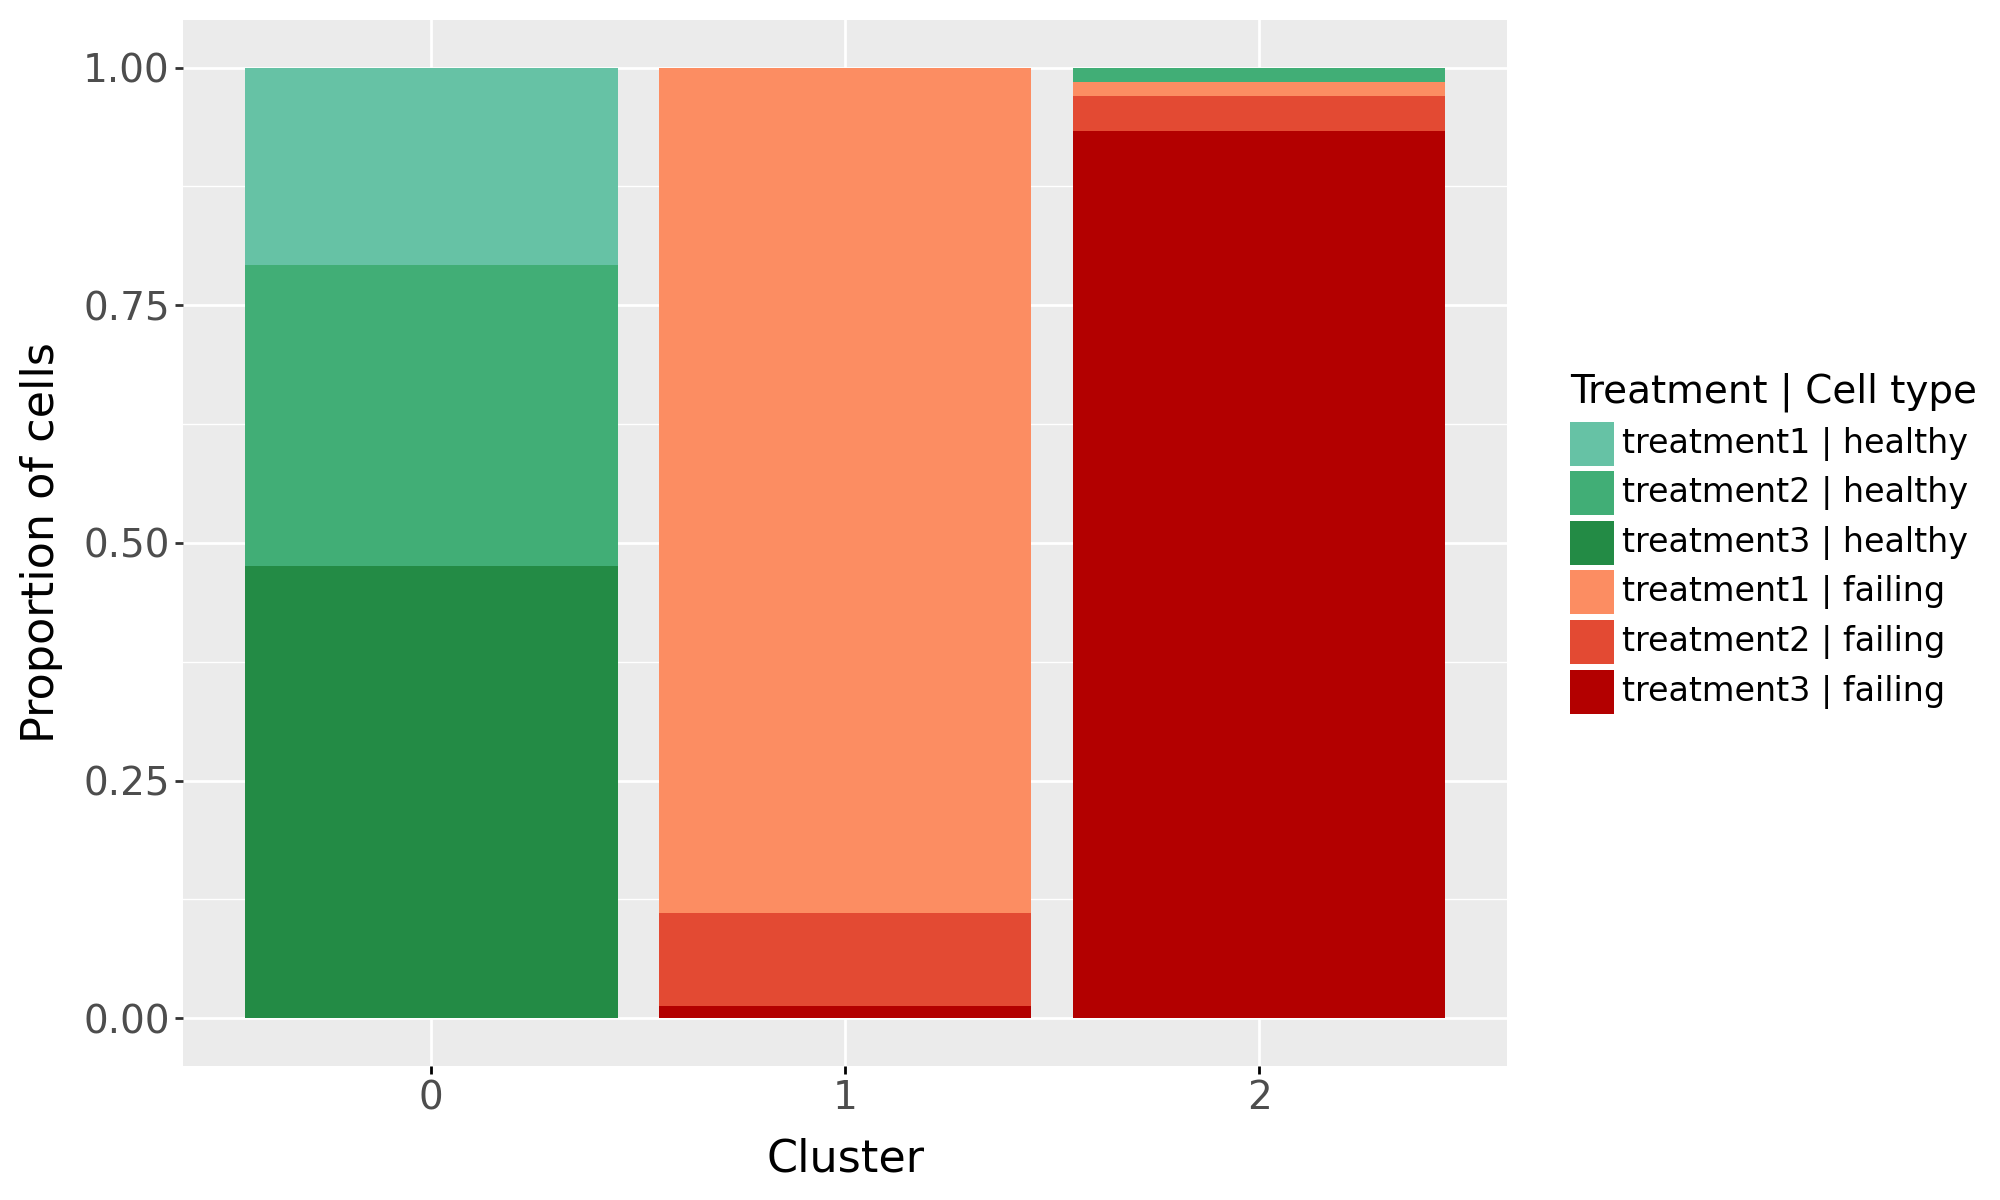

In [8]:
# Attach cluster labels to full dataframe
post_QC_clusters_df = post_QC_df.copy()
post_QC_clusters_df["cluster"] = post_cluster_labels

# Drop noise
post_QC_clusters_df = post_QC_clusters_df[post_QC_clusters_df["cluster"] != -1]

# Convert labels to string for nicer plotting
post_QC_clusters_df["cluster"] = post_QC_clusters_df["cluster"].astype(str)

# Print number of cells in each cluster
print(post_QC_clusters_df["cluster"].value_counts().sort_index())

# Prepare data
plot_df = (
    post_QC_clusters_df.groupby(["cluster", "Metadata_treatment", "Metadata_cell_type"])
    .size()
    .reset_index(name="count")
)

# Calculate proportion per cluster
plot_df["proportion"] = plot_df.groupby("cluster")["count"].transform(
    lambda x: x / x.sum()
)

# Blind treatments
treatment_blind_map = {
    "DMSO": "treatment1",
    "TGFRi": "treatment2",
    "drug_x": "treatment3",
}
plot_df["Metadata_treatment"] = plot_df["Metadata_treatment"].map(treatment_blind_map)

# Update treatment_celltype
plot_df["treatment_celltype"] = (
    plot_df["Metadata_treatment"] + " | " + plot_df["Metadata_cell_type"]
)

# Update palette dictionary with blinded names
palette_dict = {
    "treatment1 | healthy": "#66c2a5",
    "treatment2 | healthy": "#41ae76",
    "treatment3 | healthy": "#238b45",
    "treatment1 | failing": "#fc8d62",
    "treatment2 | failing": "#e34a33",
    "treatment3 | failing": "#b30000",
}

# Set categorical order with blinded names
desired_order = [
    "treatment1 | healthy",
    "treatment2 | healthy",
    "treatment3 | healthy",
    "treatment1 | failing",
    "treatment2 | failing",
    "treatment3 | failing",
]
plot_df["treatment_celltype"] = pd.Categorical(
    plot_df["treatment_celltype"], categories=desired_order, ordered=True
)


# Plot
p = (
    ggplot(plot_df, aes(x="cluster", y="proportion", fill="treatment_celltype"))
    + geom_bar(stat="identity", position=position_stack())
    + scale_fill_manual(values=palette_dict, name="Treatment | Cell type")
    + labs(
        x="Cluster",
        y="Proportion of cells",
    )
    + theme(
        figure_size=(10, 6),
        axis_text_x=element_text(size=14),
        axis_text_y=element_text(size=14),
        axis_title_x=element_text(size=16),
        axis_title_y=element_text(size=16),
        legend_title=element_text(size=14),
        legend_text=element_text(size=12),
    )
)

p.save(output_dir / "post_QC_cluster_treatment_celltype.png", dpi=300)
p